In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 1

import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../..')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensiometer import gaussian_tension


In [2]:
labels = [r"\log M_{\mathrm{c}}", r"\theta_\mathrm{ej}", r"\eta_\delta", 
          r"\mu_\beta", r"\gamma", r"\delta", r"\eta"]
ranges = {r"\log M_{\mathrm{c}}": [11, 16], r"\theta_\mathrm{ej}": [2, 8], r"\eta_\delta": [0.05, 0.4], 
          r"\mu_\beta": [0, 2], r"\gamma": [1, 4], r"\delta": [3, 11], r"\eta": [0.15, 0.3]}

# load the chains (remove no burn in since the chains have already been cleaned)
from getdist import MCSamples, plots

# the prior chain:
settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}
samples = np.loadtxt("../DMvar_SPk_emulators/BCEmu7_high_z/param_grid_prior_example.csv", delimiter=",", skiprows=1)[:, 4:]
prior_chain = MCSamples(samples=samples, names=labels, labels=labels, settings=settings, label="Prior", ranges = ranges)

# the FRB DM-z chain:
import pickle
def get_samples(mcmc_file):
    class RenameUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith("numpy._core"):
                module = module.replace("numpy._core", "numpy.core")
            return super().find_class(module, name)
    with open(mcmc_file, "rb") as f:
        results = RenameUnpickler(f).load()
    samples = results["chain"]
    samples = samples.reshape(-1, samples.shape[-1])
    # DMhost transformations
    DMhost_mean = np.exp(samples[:, -2] + ((samples[:, -1]**2)/2))
    DMhost_var = np.sqrt(np.exp(samples[:, -1]**2 - 1) * np.exp(2*samples[:, -2] + samples[:, -1]**2))
    samples[:, -2] = DMhost_mean; samples[:, -1] = DMhost_var
    return results["chain"], results["log_prob"]

settings = {'ignore_rows':0, 'smooth_scale_1D':0.5, 'smooth_scale_2D':0.99}
samples, log_prob = get_samples("data/frb_results/emcee_BCEmu7_extended.pkl") # log_prob
samples = samples[:, :, :-2]
chain = MCSamples(samples=samples, names=labels, labels=labels, loglikes=log_prob,
                  settings=settings, label="Posterior", ranges = ranges)



In [3]:
param_names = chain.getParamNames().getRunningNames()
gaussian_tension.get_Neff(chain, param_names=param_names, prior_chain=prior_chain)


1.2378116542943296

In [4]:
# do the KL decomposition on the log parameters:
KL_param_names = param_names
# compute the KL modes:
KL_eig, KL_eigv, KL_param_names = gaussian_tension.Q_UDM_KL_components(prior_chain, chain, param_names=KL_param_names)
# print:
with np.printoptions(precision=2, suppress=True):
    print('Improvement factor over the prior:', KL_eig)
    print('Improvement in error units:', np.sqrt(KL_eig-1))


Improvement factor over the prior: [6.   1.21 1.11 1.09 1.05 0.97 0.6 ]
Improvement in error units: [2.24 0.46 0.34 0.31 0.22  nan  nan]


/tmp/ipykernel_93772/3202459202.py:8: RuntimeWarning: invalid value encountered in sqrt
  print('Improvement in error units:', np.sqrt(KL_eig-1))


/tmp/ipykernel_93772/2223127432.py:16: RuntimeWarning: invalid value encountered in sqrt
  labels = [ str(t+1)+'\n ('+str(l)+')' for t,l in zip(ticks,np.round(np.sqrt(KL_eig-1.),2))]


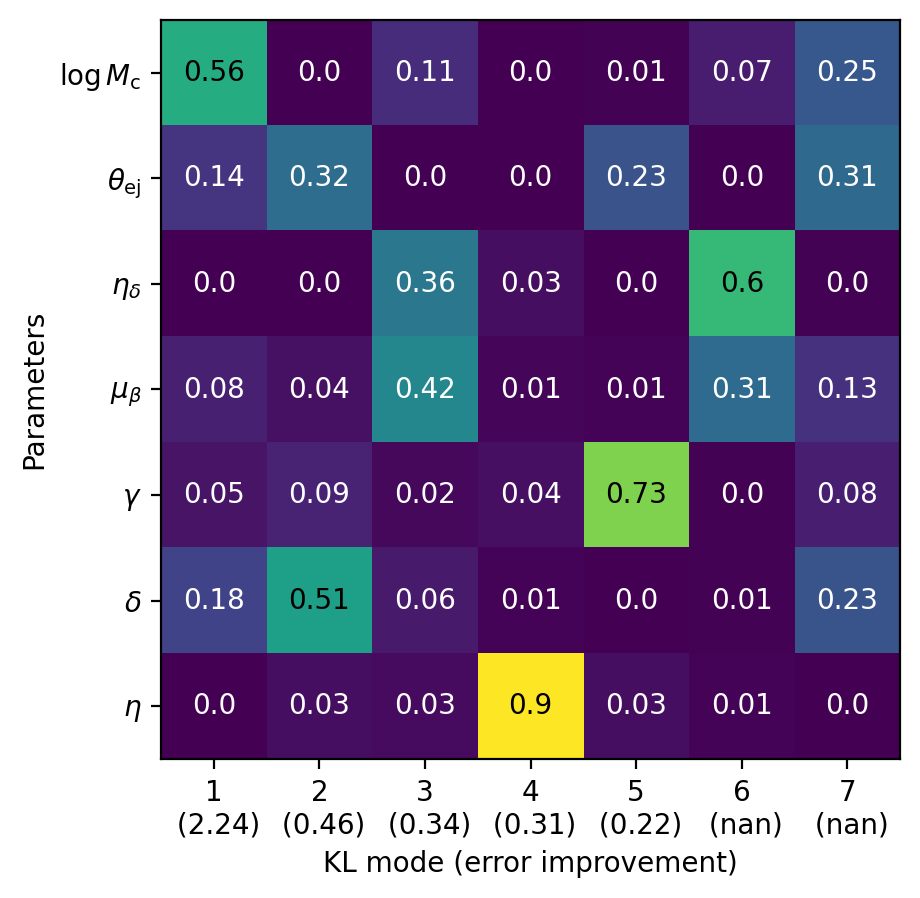

In [5]:
# First we compute the fractional Fisher matrix:
KL_param_names, KL_eig, fractional_fisher, _ = gaussian_tension.Q_UDM_fisher_components(prior_chain, chain, KL_param_names, which='1')
# plot (showing values and names):
im1 = plt.imshow( fractional_fisher, cmap='viridis')
num_params = len(fractional_fisher)
for i in range(num_params):
    for j in range(num_params):
        if fractional_fisher[j,i]>0.5:
            col = 'k'
        else:
            col = 'w'
        plt.text(i, j, np.round(fractional_fisher[j,i],2), va='center', ha='center', color=col)
plt.xlabel('KL mode (error improvement)');
plt.ylabel('Parameters');
ticks  = np.arange(num_params)
labels = [ str(t+1)+'\n ('+str(l)+')' for t,l in zip(ticks,np.round(np.sqrt(KL_eig-1.),2))]
plt.xticks(ticks, labels, horizontalalignment='center');
labels = [ '$'+chain.getParamNames().parWithName(name).label+'$' for name in KL_param_names ]
plt.yticks(ticks, labels, horizontalalignment='right');

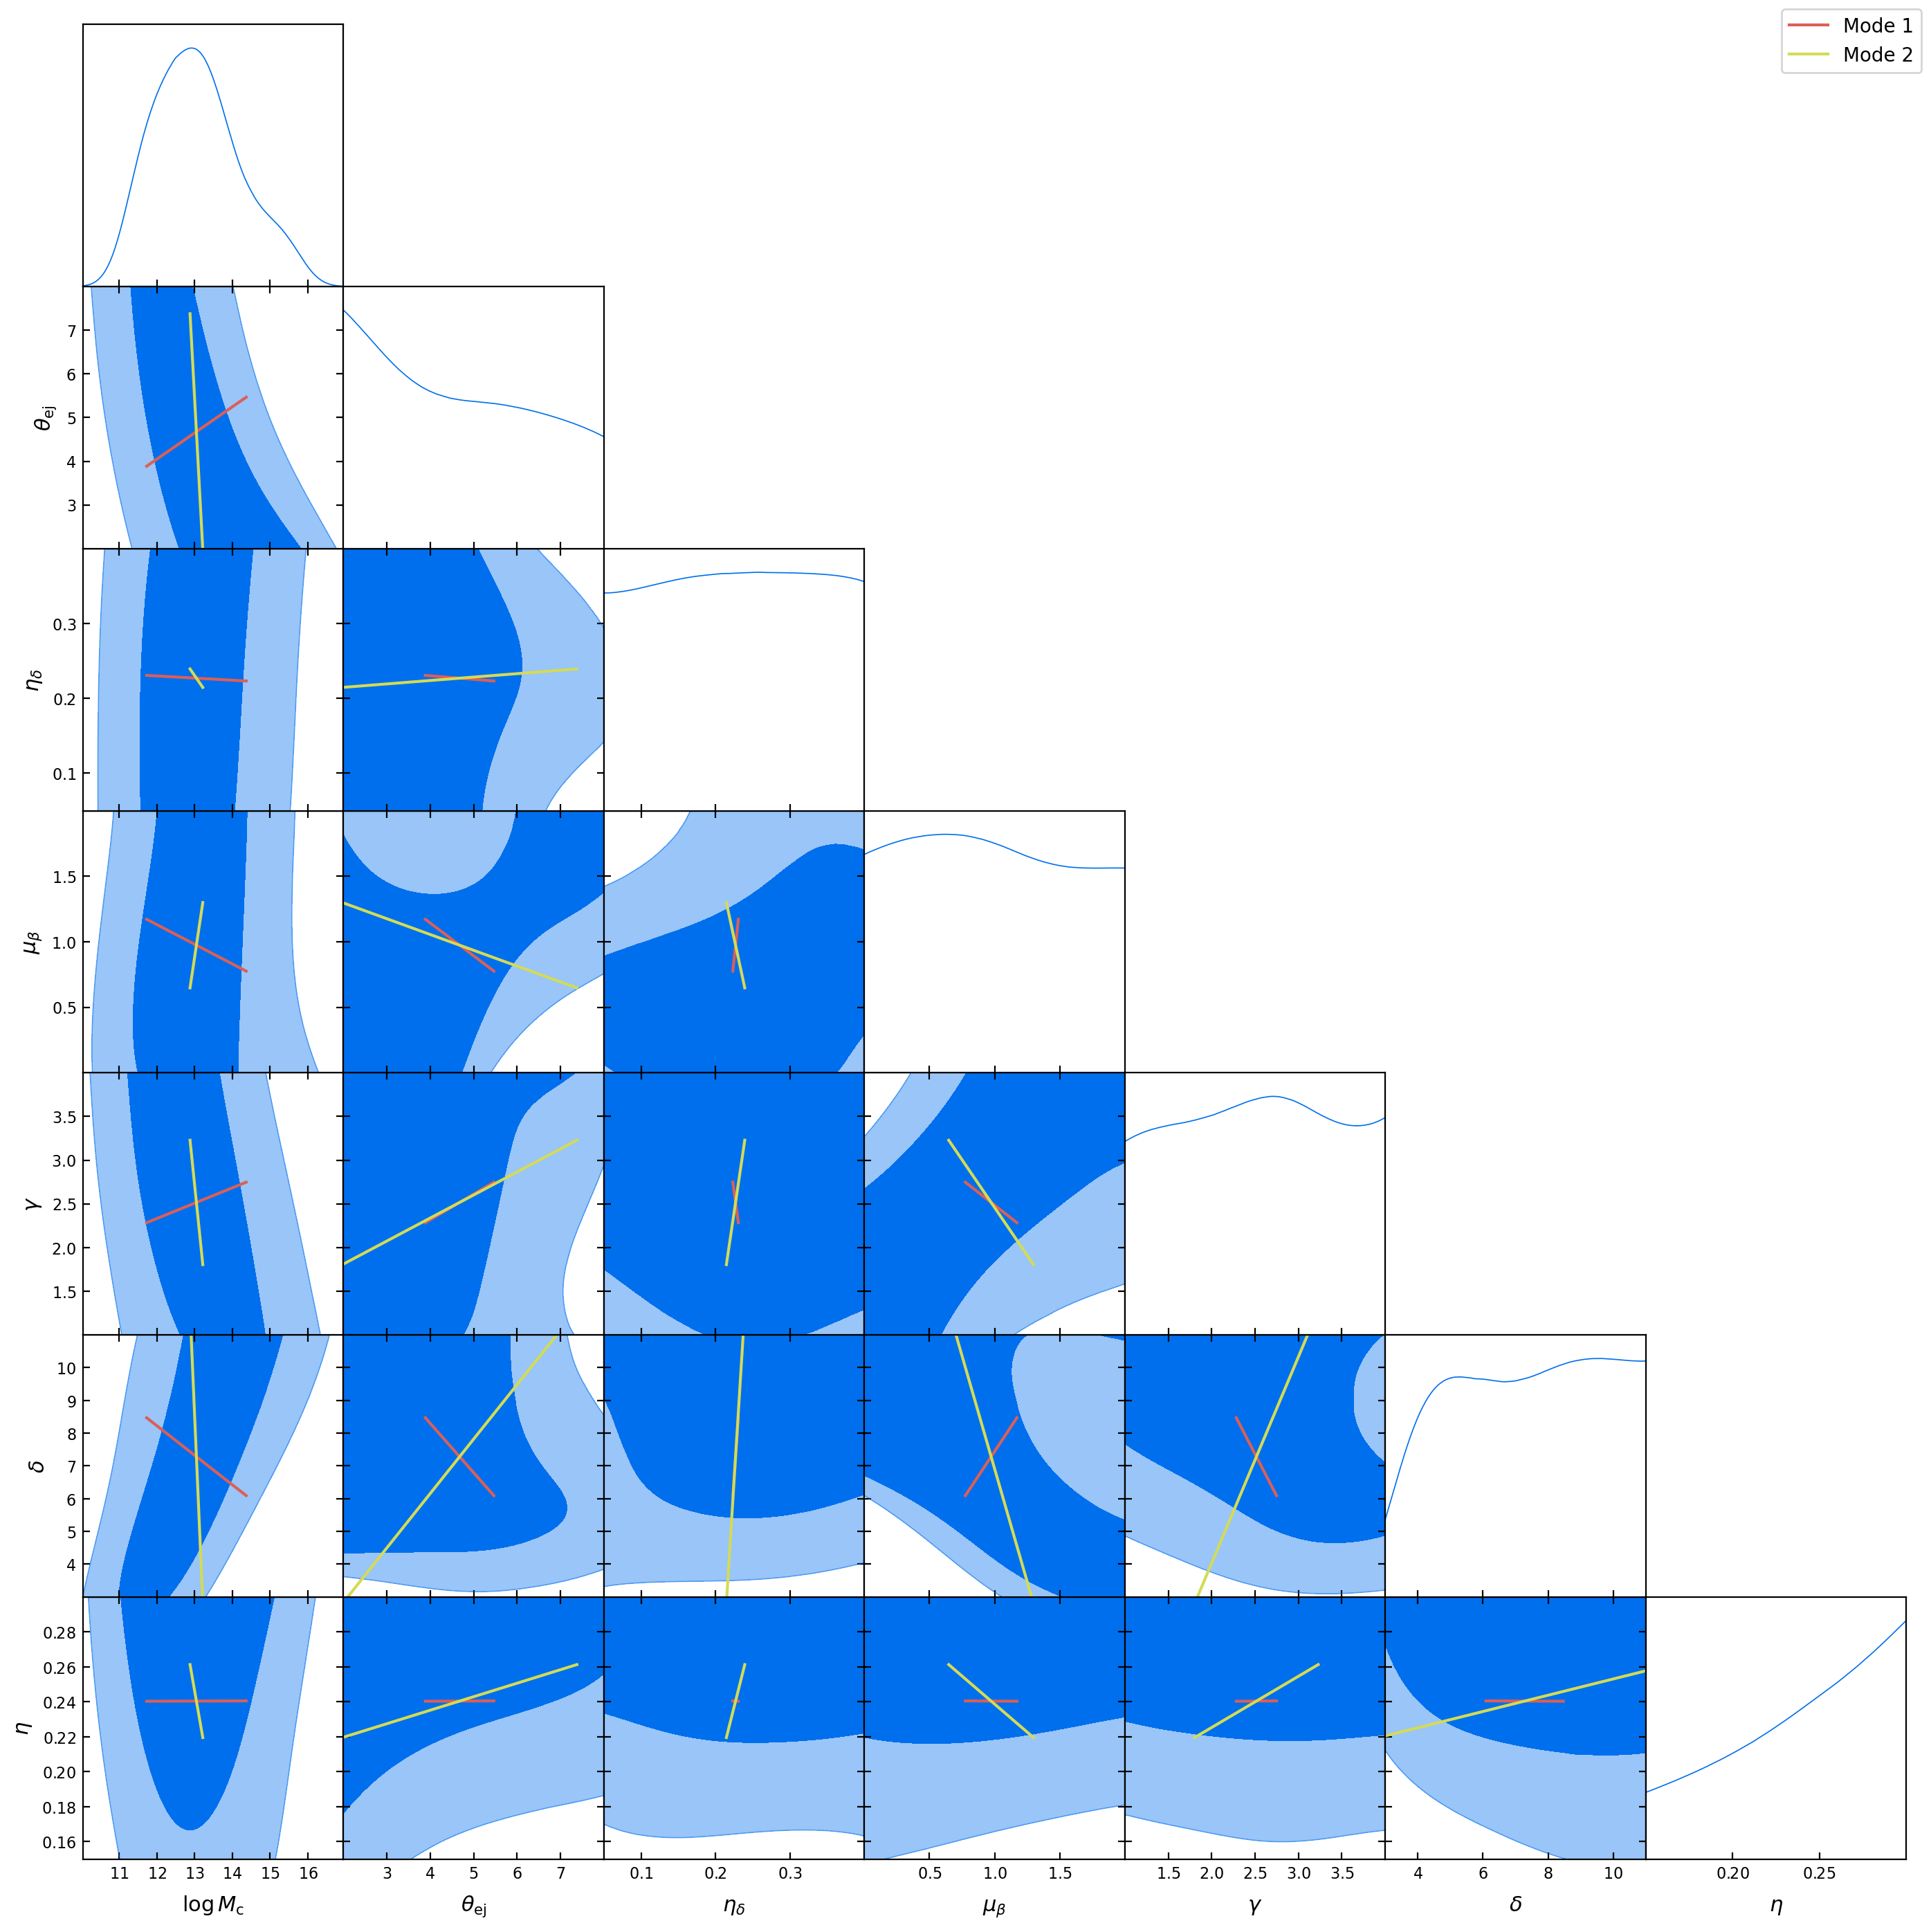

In [6]:
# compute the parameter space combinations corresponding to KL modes:
param_directions = np.linalg.inv(KL_eigv.T)
g = plots.get_subplot_plotter()
g.triangle_plot([chain], params=param_names, filled=True)
# add the modes:
for i in range(len(param_names)-1):
    for j in range(i+1,len(param_names)):
        ax = g.subplots[j,i]
        # get mean:
        m1, m2 = chain.getMeans(pars=[chain.index[name]
                       for name in [KL_param_names[i], KL_param_names[j]]])
        ax.scatter(np.exp(m1), np.exp(m2), color='k')
        alpha = 3.*np.linspace(-1.,1.,100)
        for k in range(2):
            ax.plot((m1+alpha*param_directions[:,k][i]), (m2+alpha*param_directions[:,k][j]), color=sns.hls_palette(6)[k], label='Mode '+str(k+1))
g.fig.legend(*ax.get_legend_handles_labels());


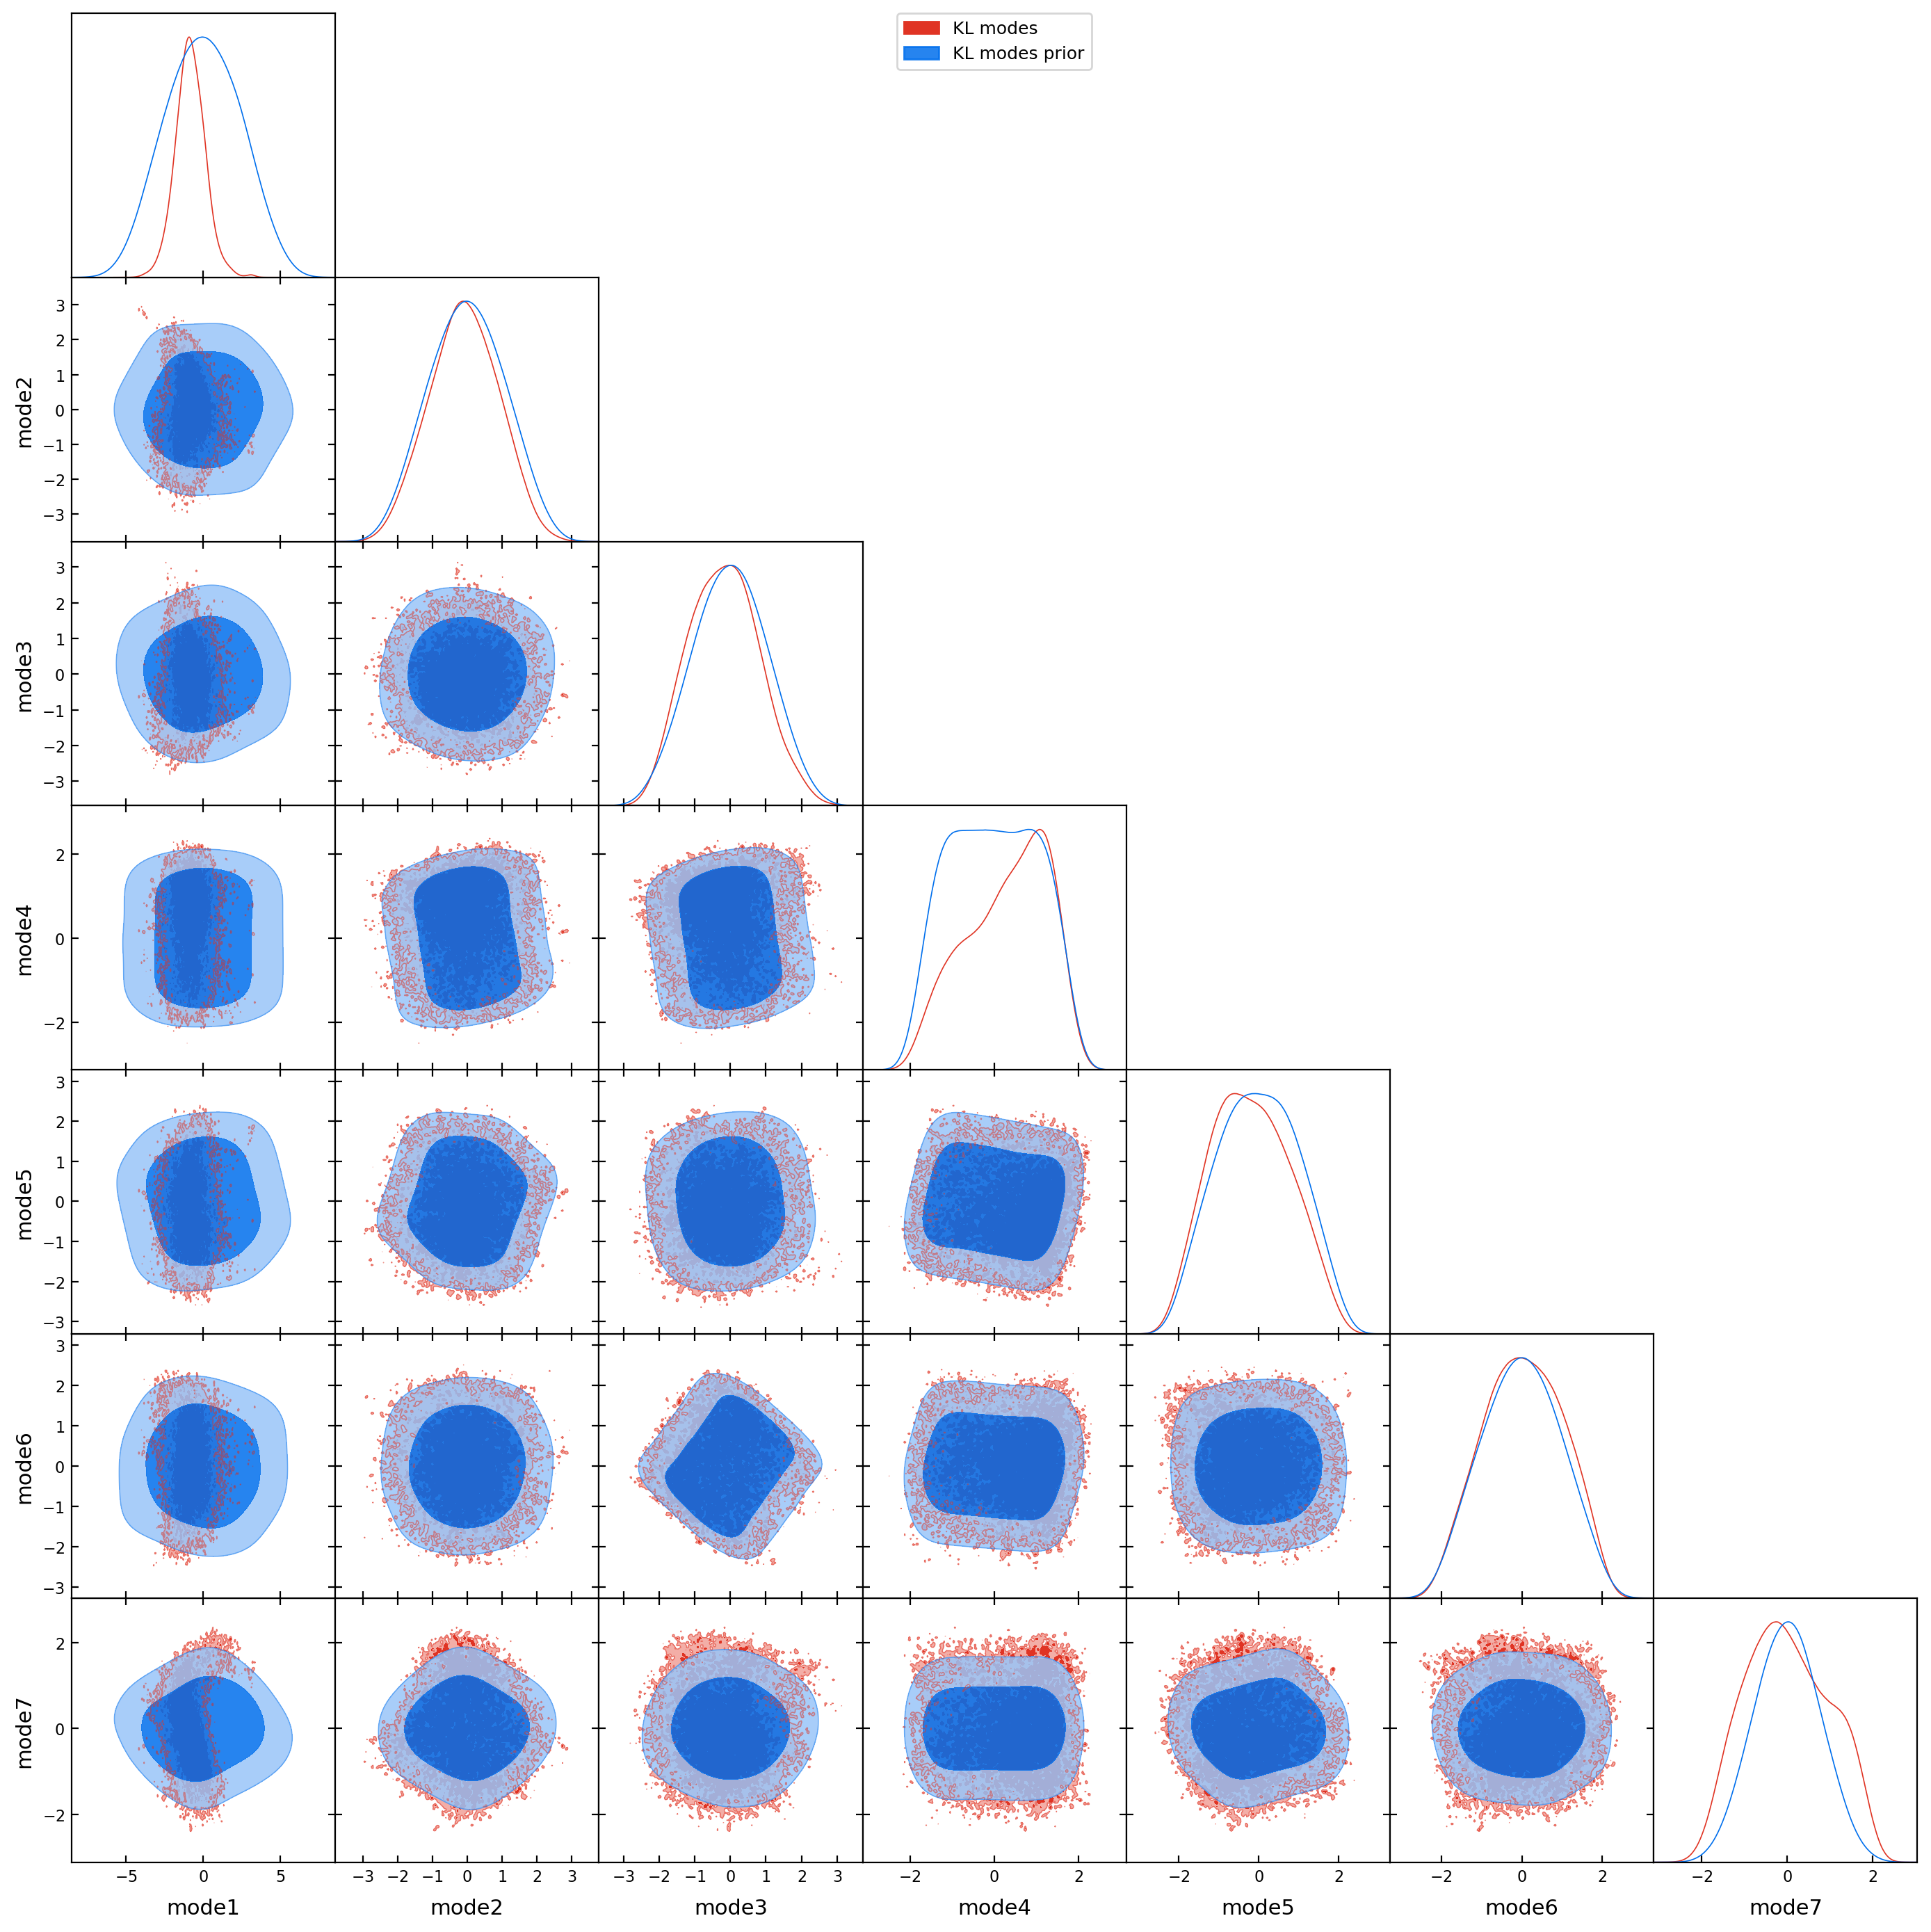

In [7]:
idx = [chain.index[name] for name in KL_param_names]
prior_mean = prior_chain.getMeans(pars=[prior_chain.index[name] for name in KL_param_names])
temp_names = ['mode'+str(i+1) for i in range(len(KL_param_names))]
KL_filtered_samples = np.dot(chain.samples[:,idx]-prior_mean, KL_eigv)
KL_chain = MCSamples(samples=KL_filtered_samples, 
                     loglikes=chain.loglikes, 
                     weights=chain.weights, 
                     names=temp_names, 
                     label='KL modes')
idx = [prior_chain.index[name] for name in KL_param_names]
KL_filtered_prior_samples = np.dot(prior_chain.samples[:,idx]-prior_mean, KL_eigv)
KL_prior_chain = MCSamples(samples=KL_filtered_prior_samples, 
                     loglikes=prior_chain.loglikes, 
                     weights=prior_chain.weights, 
                     names=temp_names, 
                     label='KL modes prior')
g = plots.get_subplot_plotter()
g.triangle_plot([KL_chain,KL_prior_chain], params=temp_names, filled=True)

In [8]:
CPCA_results = gaussian_tension.linear_CPCA_chains(prior_chain, chain, KL_param_names)
print(gaussian_tension.print_CPCA_results(CPCA_results))


CPCA for 7 parameters:

   1 : \log M_{\mathrm{c}}
   2 : \theta_\mathrm{ej}
   3 : \eta_\delta
   4 : \mu_\beta
   5 : \gamma
   6 : \delta
   7 : \eta

Neff =  1.24
Neff mode = [ 0.83 0.17 0.10 0.09 0.04 0.00 0.00]

<KL> divergence =  4.87
<KL> mode = [ 0.81 0.61 0.65 0.66 0.69 0.72 0.72]

CPC amplitudes - 1 (variance improvement per mode):
   1 :   5.0019 (   223.6 %)
   2 :   0.2089 (    45.7 %)
   3 :   0.1126 (    33.6 %)
   4 :   0.0941 (    30.7 %)
   5 :   0.0465 (    21.6 %)
   6 :  -0.0304 (     noisy)
   7 :  -0.3954 (     noisy)

CPC modes:
   1 :  -1.077  -0.645   0.003   0.162  -0.189   0.971  -0.000
   2 :   0.062  -0.990  -0.005   0.119  -0.261  -1.644  -0.008
   3 :  -0.491   0.062   0.060  -0.374  -0.119  -0.577   0.007
   4 :   0.072  -0.031  -0.019   0.067  -0.170  -0.219   0.041
   5 :  -0.106  -0.824   0.001  -0.053   0.736  -0.128   0.007

Parameter contribution to CPC-mode variance:
 mode number        :       1       2       3       4       5
 \log            

In [9]:
idx = [chain.index[name] for name in KL_param_names]
prior_mean = prior_chain.getMeans(pars=[prior_chain.index[name] for name in KL_param_names])
inv_KL_eigv = np.linalg.inv(KL_eigv)
inv_KL_eigv[1:,:]=0
KL_filtered_samples = np.dot(np.dot(chain.samples[:,idx]-prior_mean, KL_eigv), inv_KL_eigv)+prior_mean


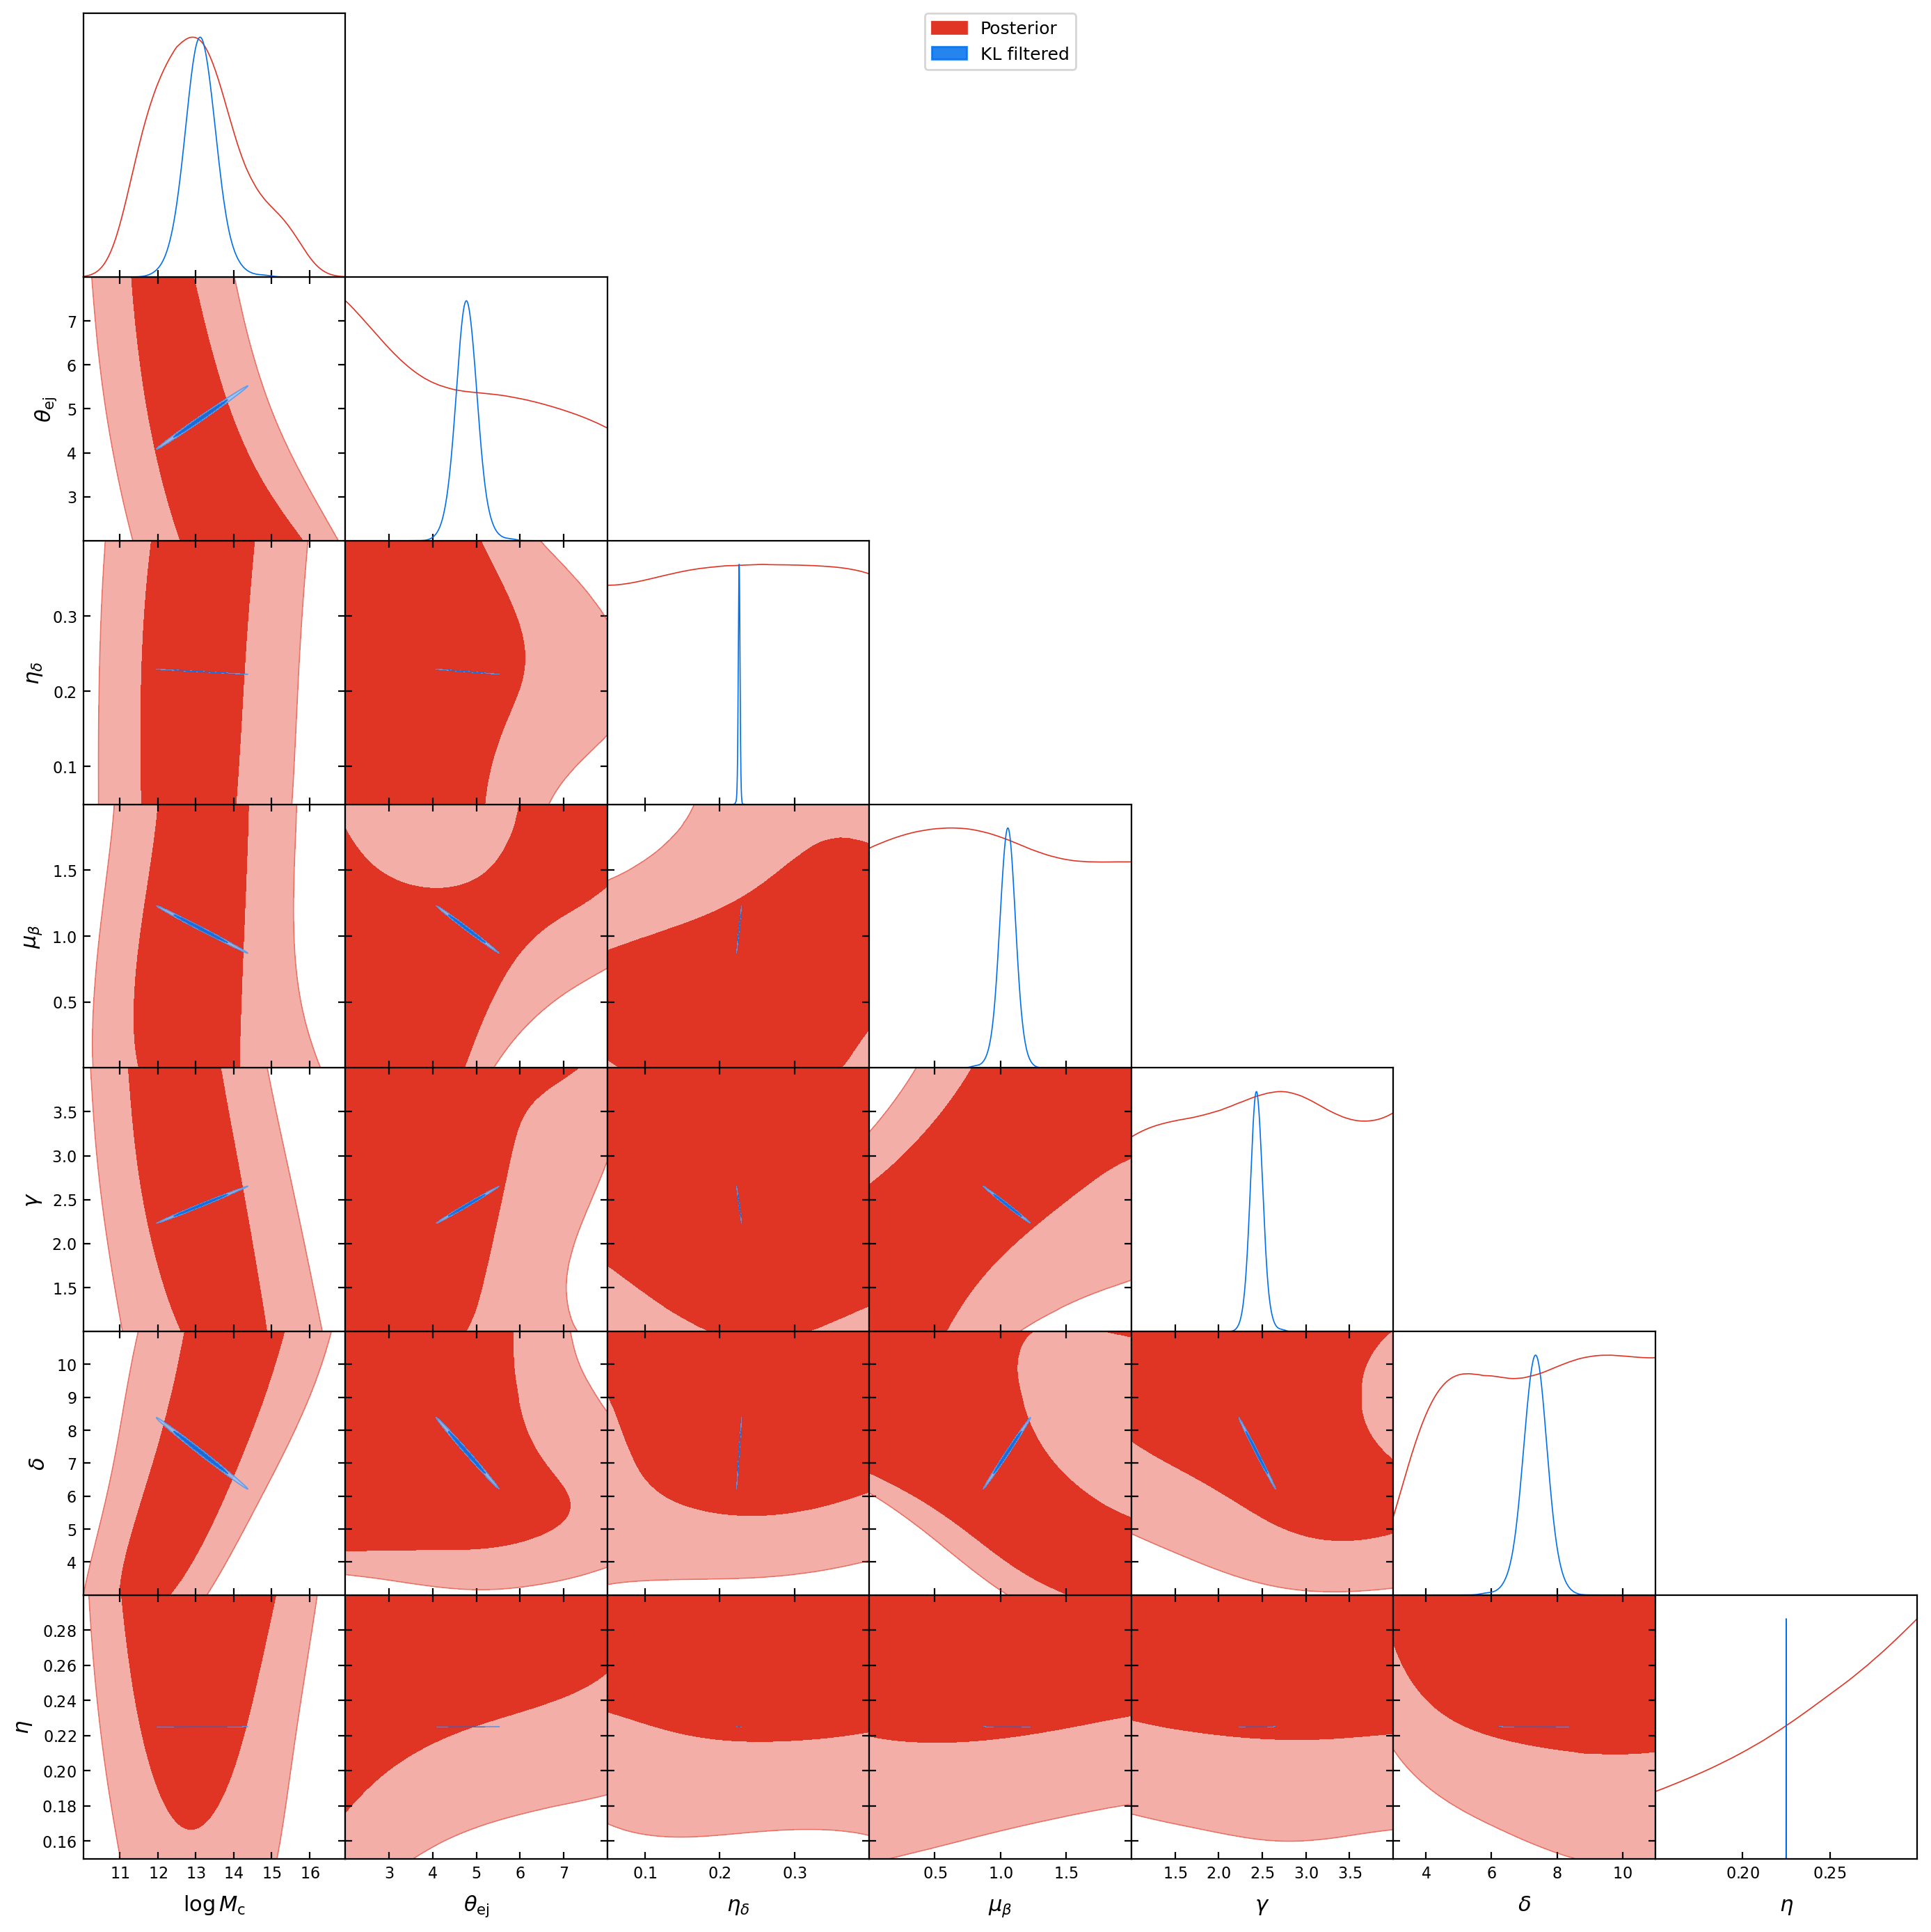

In [10]:
KL_chain = MCSamples(samples=KL_filtered_samples, 
                     loglikes=chain.loglikes, 
                     weights=chain.weights, 
                     names=param_names, 
                     labels=[ name.label for name in chain.getParamNames().parsWithNames(param_names)], 
                     label='KL filtered',
                     settings=settings)
g = plots.get_subplot_plotter()
g.triangle_plot([chain, KL_chain], params=param_names, filled=True)
